In [1]:
import torch
from pathlib import Path

from PIL import Image
from PIL import ImageOps

import numpy as np
from collections import Counter

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

import torchvision.transforms as transforms

from pprint import pprint

import torch.nn as nn

import time

In [2]:
CACHE_DIR = Path(r"D:\Intelligent_farming_system\disease_detection\cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_cache_path = CACHE_DIR / "train_images.npy"

print("Cache location:", train_cache_path)

Cache location: D:\Intelligent_farming_system\disease_detection\cache\train_images.npy


In [3]:
def create_image_cache(records, cache_path):
    if cache_path.exists():
        print("Cache already exists:", cache_path)
        return

    cached_images = np.empty(
        (len(records), 128, 128, 3),
        dtype=np.uint8
    )

    start_time = time.time()

    for index, (image_path, crop, disease) in enumerate(records):

        image = Image.open(image_path).convert("RGB")

        image = ImageOps.pad(
            image,
            (128, 128),
            color=(0, 0, 0)
        )

        cached_images[index] = np.array(image)

        if (index + 1) % 5000 == 0:
            print(
                f"Processed {index + 1}/{len(records)} images"
            )

    np.save(cache_path, cached_images)

    elapsed_time = time.time() - start_time

    print("\nCache created successfully.")
    print("Shape:", cached_images.shape)
    print("Size:", cached_images.nbytes / (1024 ** 3), "GB")
    print("Time:", elapsed_time, "seconds")

In [4]:
val_cache_path = CACHE_DIR / "val_images.npy"


def preprocess_image(index_record):
    index, record = index_record

    image_path, crop, disease = record

    image = Image.open(image_path).convert("RGB")

    image = ImageOps.pad(
        image,
        (128, 128),
        color=(0, 0, 0)
    )

    return index, np.array(image, dtype=np.uint8)


def create_cached_dataset(records, cache_path, num_threads=8):

    if cache_path.exists():
        print("Cache already exists:", cache_path)
        return

    # Create the .npy file directly on disk
    cached_images = np.lib.format.open_memmap(
        cache_path,
        mode="w+",
        dtype=np.uint8,
        shape=(len(records), 128, 128, 3)
    )

    start_time = time.time()

    with ThreadPoolExecutor(max_workers=num_threads) as executor:

        results = executor.map(
            preprocess_image,
            enumerate(records)
        )

        for index, image in results:

            cached_images[index] = image

            if (index + 1) % 1000 == 0:
                print(
                    f"Processed {index + 1}/{len(records)} images"
                )

    cached_images.flush()

    elapsed_time = time.time() - start_time

    print("\nValidation cache created successfully.")
    print("Shape:", cached_images.shape)
    print(
        "Size:",
        cached_images.nbytes / (1024 ** 3),
        "GB"
    )
    print("Time:", elapsed_time, "seconds")

In [5]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch Version: 2.14.0+cu130
CUDA: True


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


In [8]:
DATASET_DIR = Path("../disease_dataset/processed")

In [9]:
print(DATASET_DIR.resolve())

D:\Intelligent_farming_system\disease_dataset\processed


In [10]:
print([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

['banana', 'chilli', 'cotton', 'grape', 'groundnut', 'maize', 'mango', 'okra', 'paddy_doctor', 'pea', 'pigeon_pea', 'pomegranate', 'potato', 'soybean', 'sugarcane', 'tomato', 'turmeric', 'wheat']


In [11]:
print(len([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()]))

18


In [12]:
banana_dir = DATASET_DIR / "banana"

In [13]:
print([folder.name for folder in banana_dir.iterdir() if folder.is_dir()])

['Bacterial_Soft_Rot', 'Black_Sigatoka', 'Healthy', 'Panama_Disease', 'Yellow_Sigatoka']


In [14]:
print(len([folder.name for folder in banana_dir.iterdir() if folder.is_dir()]))

5


In [15]:
for class_dir in banana_dir.iterdir():
    if class_dir.is_dir():
        class_count = len(list(class_dir.iterdir()))
        print(f"{class_dir.name}: {class_count}")

Bacterial_Soft_Rot: 1078
Black_Sigatoka: 474
Healthy: 1584
Panama_Disease: 102
Yellow_Sigatoka: 264


In [16]:
image_records = []

for crop_dir in DATASET_DIR.iterdir():
    if crop_dir.is_dir():
        for disease_dir in crop_dir.iterdir():
            if disease_dir.is_dir():
                for image_path in disease_dir.iterdir():
                    if image_path.is_file():
                        image_records.append(
                            (image_path, crop_dir.name, disease_dir.name)
                        )

print(f"Total images: {len(image_records)}")

Total images: 63664


In [17]:
image_records[0]

(WindowsPath('../disease_dataset/processed/banana/Bacterial_Soft_Rot/BACTERIAL_SOFT_ROT (1).jpg'),
 'banana',
 'Bacterial_Soft_Rot')

In [18]:
print("Path   :", image_records[0][0])
print("Crop   :", image_records[0][1])
print("Disease:", image_records[0][2])

Path   : ..\disease_dataset\processed\banana\Bacterial_Soft_Rot\BACTERIAL_SOFT_ROT (1).jpg
Crop   : banana
Disease: Bacterial_Soft_Rot


In [19]:
disease_names = []

for record in image_records:
    
    disease = record[2]

    if disease not in disease_names:
        disease_names.append(disease) 

disease_names.sort()

print(f"Total disease classes: {len(disease_names)}")
print(disease_names)

Total disease classes: 52
['Alternaria', 'Alternaria_Leaf_Spot', 'Anthracnose', 'Ascochyta_Blight', 'Bacterial_Blackspot', 'Bacterial_Blight', 'Bacterial_Leaf_Blight', 'Bacterial_Leaf_Streak', 'Bacterial_Panicle_Blight', 'Bacterial_Soft_Rot', 'Bacterial_Spot', 'Black_Rot', 'Black_Sigatoka', 'Blast', 'Blotch', 'Botrytis_Blight', 'Brown_Spot', 'Cercospora', 'Cercospora_Leaf_Blight', 'Cercospora_Leaf_Spot', 'Curl_Virus', 'Die_Back', 'Downy_Mildew', 'Early_Blight', 'Esca', 'Fusarium_Wilt', 'Healthy', 'Late_Blight', 'Leaf_Blight', 'Leaf_Curly_Virus', 'Leaf_Rust', 'Leaf_Spot', 'Leaf_Spot_Early_Late', 'Maize_Leaf_Spot', 'Maize_Streak_Virus', 'Mosaic', 'Panama_Disease', 'Pea_Leaf_Roll_Virus', 'Phyllosticta_Leaf_Spot', 'Powdery_Mildew', 'Red_Rot', 'Rosette', 'Rust', 'Sooty_Mould', 'Spotted_Wilt_Virus', 'Stem_Rot', 'Sterility_Mosaic', 'Sudden_Death_Syndrome', 'Tungro', 'White_Spot', 'Yellow', 'Yellow_Sigatoka']


In [20]:
stratification_labels = []

for image_path, crop, disease in image_records:
    stratification_labels.append((crop, disease))

distribution = Counter(stratification_labels)

print(f"Number of crop disease combinations: {len(distribution)}")

for (crop, disease), count in sorted(distribution.items()):
    print(f"{crop:20s} | {disease:30s}: {count}")

Number of crop disease combinations: 82
banana               | Bacterial_Soft_Rot            : 1078
banana               | Black_Sigatoka                : 474
banana               | Healthy                       : 1584
banana               | Panama_Disease                : 102
banana               | Yellow_Sigatoka               : 264
chilli               | Bacterial_Spot                : 156
chilli               | Cercospora_Leaf_Spot          : 180
chilli               | Curl_Virus                    : 423
chilli               | Healthy                       : 458
chilli               | White_Spot                    : 195
cotton               | Bacterial_Blight              : 250
cotton               | Curl_Virus                    : 431
cotton               | Healthy                       : 257
grape                | Black_Rot                     : 808
grape                | Esca                          : 888
grape                | Healthy                       : 1109
grape        

In [21]:
small_classes = {
    key: count
    for key, count in distribution.items()
    if count < 50
}

In [22]:
for (crop, disease), count in small_classes.items():
    print(f"{crop:20s} | {disease:30s}: {count}")

pea                  | Pea_Leaf_Roll_Virus           : 40
pea                  | Stem_Rot                      : 41


In [23]:
small_classes_100 = {
    key: count
    for key, count in distribution.items()
    if count < 100
}

In [24]:
for (crop, disease), count in small_classes_100.items():
    print(f"{crop:20s} | {disease:30s}: {count}")

pea                  | Pea_Leaf_Roll_Virus           : 40
pea                  | Stem_Rot                      : 41
soybean              | Bacterial_Blight              : 99
soybean              | Cercospora_Leaf_Blight        : 99
soybean              | Healthy                       : 97
soybean              | Rust                          : 99


In [25]:
train_records, temp_records = train_test_split(
    image_records,
    test_size=0.3,
    random_state=42,
    stratify=stratification_labels
)

In [26]:
temp_labels = [
    (crop, disease)
    for _, crop, disease in temp_records
]

In [27]:
val_records, test_records = train_test_split(
    temp_records,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)


In [28]:
# create_cached_dataset(
#     val_records,
#     val_cache_path,
#     num_threads=8
# )

In [29]:
print(f"Train:      {len(train_records)}")
print(f"Validation: {len(val_records)}")
print(f"Test:       {len(test_records)}")

Train:      44564
Validation: 9550
Test:       9550


In [30]:
def count_classes(records):
    return Counter((crop, disease) for _, crop, disease in records)

In [31]:
train_distribution = count_classes(train_records)
val_distribution = count_classes(val_records)
test_distribution = count_classes(test_records)

In [32]:
print("Train classes:", len(train_distribution))
print("Validation classes:", len(val_distribution))
print("Test classes:", len(test_distribution))

Train classes: 82
Validation classes: 82
Test classes: 82


In [33]:
train_distribution

Counter({('potato', 'Late_Blight'): 4281,
         ('potato', 'Early_Blight'): 3362,
         ('potato', 'Healthy'): 3220,
         ('pea', 'Ascochyta_Blight'): 2687,
         ('pea', 'Healthy'): 2568,
         ('paddy_doctor', 'Healthy'): 1235,
         ('paddy_doctor', 'Blast'): 1217,
         ('banana', 'Healthy'): 1109,
         ('pea', 'Botrytis_Blight'): 1020,
         ('pomegranate', 'Healthy'): 1015,
         ('maize', 'Maize_Leaf_Spot'): 883,
         ('pomegranate', 'Anthracnose'): 816,
         ('grape', 'Healthy'): 776,
         ('paddy_doctor', 'Tungro'): 762,
         ('banana', 'Bacterial_Soft_Rot'): 755,
         ('maize', 'Maize_Streak_Virus'): 703,
         ('pomegranate', 'Bacterial_Blight'): 676,
         ('paddy_doctor', 'Brown_Spot'): 675,
         ('tomato', 'Late_Blight'): 633,
         ('grape', 'Esca'): 622,
         ('pomegranate', 'Alternaria'): 620,
         ('grape', 'Black_Rot'): 566,
         ('grape', 'Leaf_Blight'): 470,
         ('pea', 'Anthracnose')

BACTERIAL_SOFT_ROT (1).jpg
Crop: banana
Disease: Bacterial_Soft_Rot
Size: (256, 256)


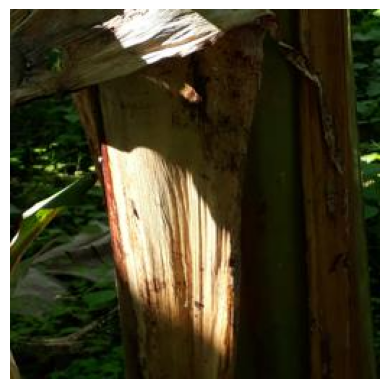

In [34]:
image_path, crop, disease = image_records[0]

image = Image.open(image_path)

print(image_path.name)
print(f"Crop: {crop}")
print(f"Disease: {disease}")
print(f"Size: {image.size}")

plt.imshow(image)
plt.axis("off")
plt.show()

In [35]:
def get_image_size(image_path):
    with Image.open(image_path) as image:
        return image.size

In [36]:
image_sizes = Counter()

with ThreadPoolExecutor() as executor:
    sizes = executor.map(
        get_image_size,
        [image_path for image_path, _, _ in image_records]
    )

for size in sizes:
    image_sizes[size] += 1

print(f"Number of different image sizes: {len(image_sizes)}")

for size, count in image_sizes.most_common():
    print(f"{size}: {count}")

Number of different image sizes: 648
(1080, 1080): 14652
(480, 640): 7367
(719, 1600): 5290
(3120, 3120): 5099
(256, 256): 4874
(224, 224): 3158
(8160, 3672): 2605
(400, 400): 2476
(1600, 719): 1754
(4624, 3472): 1720
(3468, 4624): 1614
(255, 255): 1584
(1000, 1000): 1412
(6000, 4000): 1032
(640, 640): 1012
(493, 1040): 958
(800, 800): 938
(3024, 2016): 859
(4000, 3000): 790
(4624, 3468): 780
(780, 1040): 580
(5472, 3648): 246
(1040, 493): 217
(585, 1040): 161
(4496, 3000): 141
(1040, 780): 75
(4608, 3456): 63
(758, 1600): 58
(588, 1280): 50
(3456, 4608): 42
(899, 1599): 41
(750, 1000): 27
(622, 1280): 21
(960, 1280): 20
(900, 1600): 18
(1600, 758): 13
(1040, 585): 13
(661, 661): 12
(493, 983): 12
(3482, 3402): 11
(493, 986): 11
(612, 816): 10
(633, 633): 9
(700, 700): 9
(621, 621): 9
(653, 653): 9
(612, 612): 9
(520, 520): 9
(654, 654): 9
(740, 740): 9
(493, 988): 9
(607, 607): 8
(762, 762): 8
(709, 709): 8
(3893, 3474): 8
(3657, 3366): 8
(3767, 3340): 8
(2380, 2536): 8
(1724, 1784): 

In [37]:
for image_path, crop, disease in image_records:
    with Image.open(image_path) as image:
        if image.height != image.width:
            break

image = Image.open(image_path).convert("RGB")

In [38]:
direct_resize = image.resize((128, 128))

In [39]:
aspect_resize = image.copy()

aspect_resize.thumbnail((128, 128))

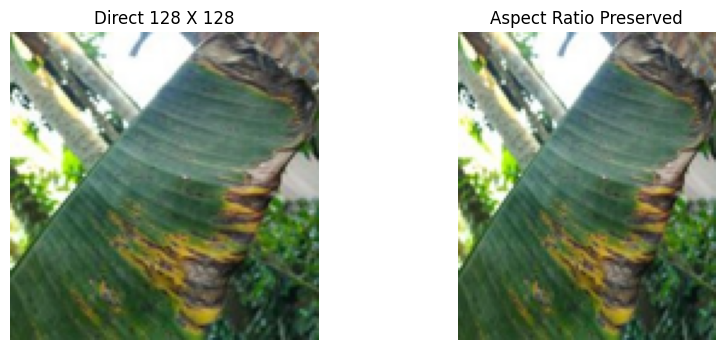

Original: (191, 229)
Direct resize: (128, 128)
Aspect preserved: (107, 128)


In [40]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(direct_resize)
plt.title("Direct 128 X 128")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aspect_resize)
plt.title("Aspect Ratio Preserved")
plt.axis("off")

plt.show()

print("Original:", image.size)
print("Direct resize:", direct_resize.size)
print("Aspect preserved:", aspect_resize.size)

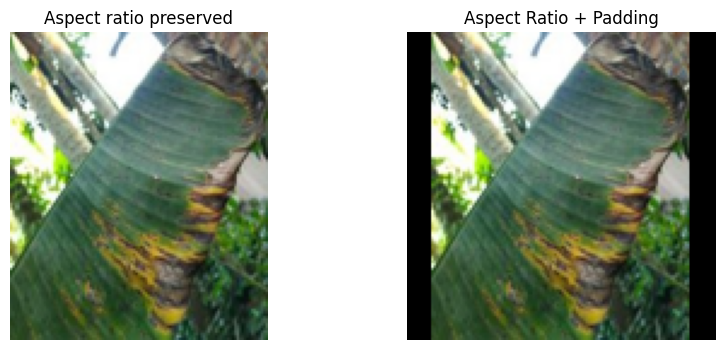

Original: (191, 229)
Final: (128, 128)


In [41]:
resized = image.copy()
resized.thumbnail((128, 128))

padded = ImageOps.pad(
    resized,
    (128, 128),
    color=(0, 0, 0)
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(aspect_resize)
plt.title("Aspect ratio preserved")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded)
plt.title("Aspect Ratio + Padding")
plt.axis("off")

plt.show()

print("Original:", image.size)
print("Final:", padded.size)

In [42]:
train_transform = transforms.Compose([
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.Lambda(
        lambda image: ImageOps.pad(
            image,
            (128, 128),
            color=(0, 0, 0)
        )
    ),

    transforms.RandomRotation(15),

    transforms.ToTensor()
])

In [43]:
val_test_transform = transforms.Compose([
    transforms.Lambda(
        lambda image: ImageOps.pad(
            image,
            (128, 128),
            color=(0, 0, 0)
        )
    ),
    transforms.ToTensor()
])

In [44]:
transformed_image = train_transform(image)

print(f"Type: {type(transformed_image)}")
print(f"Shape: {transformed_image.shape}")
print(f"Maximum Pixel Value: {transformed_image.max().item()}")
print(f"Minimum Pixel Value: {transformed_image.min().item()}")

Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 128, 128])
Maximum Pixel Value: 1.0
Minimum Pixel Value: 0.0


In [45]:
crops = sorted({
    crop 
    for _, crop, _ in image_records
})

crop_to_index = {
    crop: index
    for index, crop in enumerate(crops)
}

print(f"Number of crops: {len(crop_to_index)}")
print(crop_to_index)

Number of crops: 18
{'banana': 0, 'chilli': 1, 'cotton': 2, 'grape': 3, 'groundnut': 4, 'maize': 5, 'mango': 6, 'okra': 7, 'paddy_doctor': 8, 'pea': 9, 'pigeon_pea': 10, 'pomegranate': 11, 'potato': 12, 'soybean': 13, 'sugarcane': 14, 'tomato': 15, 'turmeric': 16, 'wheat': 17}


In [46]:
disease_to_index = {}

for crop in crops:

    disease = sorted({
        disease
        for _, record_crop, disease in image_records
        if record_crop == crop
    })

    disease_to_index[crop] = {
        disease: index
        for index, disease in enumerate(disease)
    }

In [47]:
print(disease_to_index)

{'banana': {'Bacterial_Soft_Rot': 0, 'Black_Sigatoka': 1, 'Healthy': 2, 'Panama_Disease': 3, 'Yellow_Sigatoka': 4}, 'chilli': {'Bacterial_Spot': 0, 'Cercospora_Leaf_Spot': 1, 'Curl_Virus': 2, 'Healthy': 3, 'White_Spot': 4}, 'cotton': {'Bacterial_Blight': 0, 'Curl_Virus': 1, 'Healthy': 2}, 'grape': {'Black_Rot': 0, 'Esca': 1, 'Healthy': 2, 'Leaf_Blight': 3}, 'groundnut': {'Alternaria_Leaf_Spot': 0, 'Healthy': 1, 'Leaf_Spot_Early_Late': 2, 'Rosette': 3, 'Rust': 4}, 'maize': {'Healthy': 0, 'Maize_Leaf_Spot': 1, 'Maize_Streak_Virus': 2}, 'mango': {'Bacterial_Blackspot': 0, 'Die_Back': 1, 'Healthy': 2, 'Sooty_Mould': 3}, 'okra': {'Alternaria_Leaf_Spot': 0, 'Cercospora_Leaf_Spot': 1, 'Downy_Mildew': 2, 'Healthy': 3, 'Leaf_Curly_Virus': 4, 'Phyllosticta_Leaf_Spot': 5}, 'paddy_doctor': {'Bacterial_Leaf_Blight': 0, 'Bacterial_Leaf_Streak': 1, 'Bacterial_Panicle_Blight': 2, 'Blast': 3, 'Brown_Spot': 4, 'Downy_Mildew': 5, 'Healthy': 6, 'Tungro': 7}, 'pea': {'Anthracnose': 0, 'Ascochyta_Blight': 1

In [48]:
pprint(disease_to_index, sort_dicts=False, width=100)

{'banana': {'Bacterial_Soft_Rot': 0,
            'Black_Sigatoka': 1,
            'Healthy': 2,
            'Panama_Disease': 3,
            'Yellow_Sigatoka': 4},
 'chilli': {'Bacterial_Spot': 0,
            'Cercospora_Leaf_Spot': 1,
            'Curl_Virus': 2,
            'Healthy': 3,
            'White_Spot': 4},
 'cotton': {'Bacterial_Blight': 0, 'Curl_Virus': 1, 'Healthy': 2},
 'grape': {'Black_Rot': 0, 'Esca': 1, 'Healthy': 2, 'Leaf_Blight': 3},
 'groundnut': {'Alternaria_Leaf_Spot': 0,
               'Healthy': 1,
               'Leaf_Spot_Early_Late': 2,
               'Rosette': 3,
               'Rust': 4},
 'maize': {'Healthy': 0, 'Maize_Leaf_Spot': 1, 'Maize_Streak_Virus': 2},
 'mango': {'Bacterial_Blackspot': 0, 'Die_Back': 1, 'Healthy': 2, 'Sooty_Mould': 3},
 'okra': {'Alternaria_Leaf_Spot': 0,
          'Cercospora_Leaf_Spot': 1,
          'Downy_Mildew': 2,
          'Healthy': 3,
          'Leaf_Curly_Virus': 4,
          'Phyllosticta_Leaf_Spot': 5},
 'paddy_doctor

In [49]:
class DiseaseDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        records,
        crop_to_index,
        disease_to_index,
        transform=None
    ):

        self.records = records
        self.crop_to_index = crop_to_index
        self.disease_to_index = disease_to_index
        self.transform = transform


    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image_path, crop, disease = self.records[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        crop_label = self.crop_to_index[crop]
        disease_label = self.disease_to_index[crop][disease]

        return image, crop_label, disease_label

In [50]:
sample_dataset = DiseaseDataset(
    train_records,
    crop_to_index,
    disease_to_index,
    transform=train_transform
)

In [51]:
sample_image, sample_crop, sample_disease = sample_dataset[0]

In [52]:
print("Image shape:", sample_image.shape)
print("Crop label:", sample_crop)
print("Disease label:", sample_disease)
print("Data type: ", type(sample_image))

Image shape: torch.Size([3, 128, 128])
Crop label: 12
Disease label: 1
Data type:  <class 'torch.Tensor'>


In [53]:
type(train_records)

list

In [54]:
train_records[0]

(WindowsPath('../disease_dataset/processed/potato/Healthy/healthy-leaf (3925).jpg'),
 'potato',
 'Healthy')

In [55]:
# create_image_cache(
#     train_records,
#     train_cache_path
# )

In [56]:
train_dataset = DiseaseDataset(
    train_records,
    crop_to_index,
    disease_to_index,
    transform=train_transform
)

val_dataset = DiseaseDataset(
    val_records,
    crop_to_index,
    disease_to_index,
    transform=val_test_transform
)

test_dataset = DiseaseDataset(
    test_records,
    crop_to_index,
    disease_to_index,
    transform=val_test_transform
)

In [57]:
len(train_dataset)

44564

In [58]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [59]:
images, crop_labels, disease_labels = next(iter(train_loader))

In [60]:
print("Images:", images.shape)
print("Crop labels:", crop_labels.shape)
print("Disease labels:", disease_labels.shape)

Images: torch.Size([32, 3, 128, 128])
Crop labels: torch.Size([32])
Disease labels: torch.Size([32])


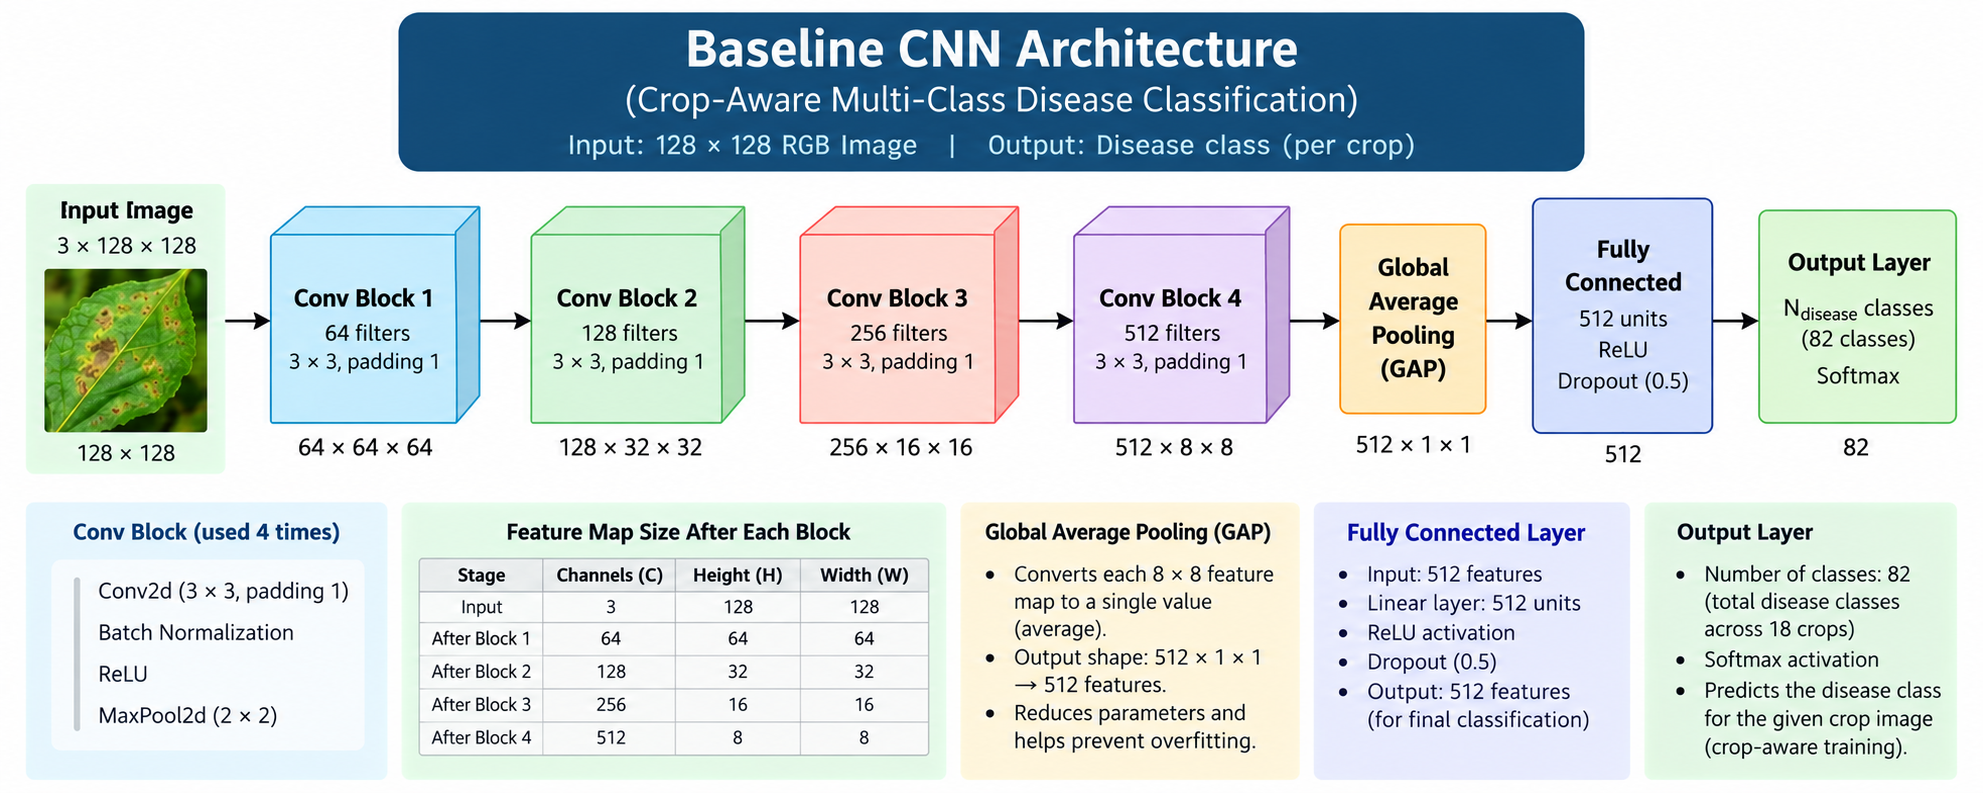

In [61]:
class ConvBlock(nn.Module):

    def __init__(self, in_channel, out_channel):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channel,
                out_channels=out_channel,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

    def forward(self, x):
        return self.block(x)

In [62]:
class BaselineCNN(nn.Module):

    def __init__(self, crops, disease_to_index):
        super().__init__()

        self.features = nn.Sequential(

            ConvBlock(3, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            ConvBlock(256, 512),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.disease_heads = nn.ModuleList(
            [
                nn.Linear(512, len(disease_to_index[crop]))
                for crop in crops
            ]
        )


    def forward(self, x, crop_labels):
        x = self.features(x)
        x = self.classifier(x)

        outputs = [None] * len(self.disease_heads)

        for crop_index in torch.unique(crop_labels):

            mask = crop_labels == crop_index

            crop_features = x[mask]

            crop_output = self.disease_heads[crop_index](crop_features)

            outputs[crop_index] = crop_output

        return outputs

In [63]:
class CachedDiseaseDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        records,
        cache_path,
        crop_to_index,
        disease_to_index,
        training=False
    ):
        self.records = records
        self.crop_to_index = crop_to_index
        self.disease_to_index = disease_to_index
        self.training = training

        # Load the cache without copying the whole 2 GB file into RAM
        self.images = np.load(
            cache_path,
            mmap_mode="r"
        )

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):

        image = self.images[index]

        # Convert HWC → CHW
        image = torch.from_numpy(
            image.copy()
        ).permute(2, 0, 1)

        # Random horizontal flip during training
        if self.training:
            if torch.rand(1).item() < 0.5:
                image = torch.flip(
                    image,
                    dims=[2]
                )

        # uint8 [0,255] → float32 [0,1]
        image = image.float() / 255.0

        _, crop, disease = self.records[index]

        crop_label = self.crop_to_index[crop]
        disease_label = self.disease_to_index[crop][disease]

        return image, crop_label, disease_label

In [64]:
model = BaselineCNN(
    crops=crops,
    disease_to_index=disease_to_index
)

In [65]:
images, crop_labels, disease_labels = next(iter(train_loader))

In [66]:
outputs = model(images, crop_labels)

In [67]:
for crop_index, output in enumerate(outputs):

    if output is not None:
        print(
            f"Crop: {crops[crop_index]:15} | "
            f"Samples: {output.shape[0]:2} | "
            f"Disease Classes: {output.shape[1]}"
        )

Crop: chilli          | Samples:  3 | Disease Classes: 5
Crop: grape           | Samples:  2 | Disease Classes: 4
Crop: groundnut       | Samples:  2 | Disease Classes: 5
Crop: maize           | Samples:  1 | Disease Classes: 3
Crop: okra            | Samples:  1 | Disease Classes: 6
Crop: paddy_doctor    | Samples:  2 | Disease Classes: 8
Crop: pea             | Samples:  6 | Disease Classes: 9
Crop: pomegranate     | Samples:  5 | Disease Classes: 5
Crop: potato          | Samples:  6 | Disease Classes: 3
Crop: soybean         | Samples:  1 | Disease Classes: 5
Crop: sugarcane       | Samples:  3 | Disease Classes: 5


In [68]:
criterion = nn.CrossEntropyLoss(reduction="sum")

In [69]:
def calculate_loss(outputs, crop_labels, disease_labels, criterion):

    total_loss = 0.0

    for crop_index in torch.unique(crop_labels):

        crop_index = crop_index.item()

        mask = crop_labels == crop_index

        crop_output = outputs[crop_index]

        crop_disease_label = disease_labels[mask]

        crop_loss = criterion(
            crop_output,
            crop_disease_label
        )

        total_loss += crop_loss

    total_loss = total_loss / len(disease_labels)

    return total_loss

In [70]:
loss = calculate_loss(
    outputs,
    crop_labels,
    disease_labels,
    criterion
)

In [71]:
print(loss)
print(loss.shape)

tensor(1.6304, grad_fn=<DivBackward0>)
torch.Size([])


In [72]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [73]:
print(device)

cuda


In [74]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3050 A Laptop GPU'

In [75]:
model = model.to(device)

In [76]:
print(next(model.parameters()).device)

cuda:0


In [77]:
images, crop_labels, disease_labels = next(iter(train_loader))

In [78]:
images = images.to(device)
crop_labels = crop_labels.to(device)
disease_labels = disease_labels.to(device)

In [79]:
images.device
crop_labels.device
disease_labels.device

device(type='cuda', index=0)

In [80]:
outputs = model(
    images,
    crop_labels
)

In [81]:
print(type(outputs))
print(len(outputs))

<class 'list'>
18


In [82]:
for crop_index, crop_output in enumerate(outputs):

    if crop_output is not None:

        print(
            crops[crop_index],
            "->",
            crop_output.shape
        )

banana -> torch.Size([2, 5])
cotton -> torch.Size([1, 3])
grape -> torch.Size([3, 4])
groundnut -> torch.Size([1, 5])
mango -> torch.Size([1, 4])
okra -> torch.Size([1, 6])
paddy_doctor -> torch.Size([3, 8])
pea -> torch.Size([5, 9])
pigeon_pea -> torch.Size([2, 3])
pomegranate -> torch.Size([2, 5])
potato -> torch.Size([6, 3])
sugarcane -> torch.Size([2, 5])
tomato -> torch.Size([3, 4])


In [83]:
loss = calculate_loss(
    outputs,
    crop_labels,
    disease_labels,
    criterion
)

In [84]:
print(loss)

tensor(1.5776, device='cuda:0', grad_fn=<DivBackward0>)


In [85]:
cached_train_dataset = CachedDiseaseDataset(
    train_records,
    train_cache_path,
    crop_to_index,
    disease_to_index,
    training=True
)

print("Cached dataset size:", len(cached_train_dataset))

Cached dataset size: 44564


In [86]:
cached_val_dataset = CachedDiseaseDataset(
    val_records,
    val_cache_path,
    crop_to_index,
    disease_to_index,
    training=False
)

cached_train_loader = torch.utils.data.DataLoader(
    cached_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

cached_val_loader = torch.utils.data.DataLoader(
    cached_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Cached train dataset:", len(cached_train_dataset))
print("Cached validation dataset:", len(cached_val_dataset))

Cached train dataset: 44564
Cached validation dataset: 9550


In [87]:
import time

start_time = time.time()

for batch_index, (images, crop_labels, disease_labels) in enumerate(cached_train_loader):

    if batch_index == 20:
        break

elapsed_time = time.time() - start_time

print("Time for 20 batches:", elapsed_time, "seconds")
print("Average time per batch:", elapsed_time / 20, "seconds")

Time for 20 batches: 0.3628411293029785 seconds
Average time per batch: 0.018142056465148926 seconds


In [88]:
torch.backends.cudnn.benchmark = True

print("cuDNN benchmark:", torch.backends.cudnn.benchmark)

cuDNN benchmark: True


In [89]:
scaler = torch.amp.GradScaler("cuda")

print("AMP scaler created:", scaler)

AMP scaler created: <torch.amp.grad_scaler.GradScaler object at 0x0000022E9FD92A50>


In [90]:
# ============================================================
# MODEL PATH
# ============================================================

MODEL_PATH = Path(
    r"D:\Intelligent_farming_system\disease_detection\models\disease_cnn_30_epochs.pth"
)

num_epochs = 30

train_losses = []
val_losses = []


# ============================================================
# CHECK IF TRAINED MODEL ALREADY EXISTS
# ============================================================

if MODEL_PATH.exists():

    print("=" * 60)
    print("TRAINED MODEL FOUND")
    print("=" * 60)
    print(f"Path: {MODEL_PATH}")
    print("Loading saved weights...")
    print("=" * 60)

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device,
            weights_only=True
        )
    )

    model.to(device)
    model.eval()

    print("MODEL LOADED SUCCESSFULLY ✅")
    print("Skipping 30-epoch training.")
    print("=" * 60)


# ============================================================
# TRAIN ONLY IF MODEL DOES NOT EXIST
# ============================================================

else:

    print("=" * 60)
    print("NO TRAINED MODEL FOUND")
    print("=" * 60)
    print("Starting 30-epoch training...")
    print("=" * 60)

    for epoch in range(num_epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        start_time = time.time()

        epoch_loss = 0.0

        total_train_batches = len(cached_train_loader)

        print()
        print("=" * 60)
        print(f"STARTING EPOCH {epoch + 1}/{num_epochs}")
        print(f"Total training batches: {total_train_batches}")
        print("=" * 60)

        for batch_idx, (
            images,
            crop_labels,
            disease_labels
        ) in enumerate(cached_train_loader):

            images = images.to(
                device,
                non_blocking=True
            )

            crop_labels = crop_labels.to(
                device,
                non_blocking=True
            )

            disease_labels = disease_labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images,
                    crop_labels
                )

                loss = calculate_loss(
                    outputs,
                    crop_labels,
                    disease_labels,
                    criterion
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

            epoch_loss += loss.item()

            # -------------------------
            # Training progress
            # -------------------------

            if (
                (batch_idx + 1) % 100 == 0
                or batch_idx == 0
                or batch_idx + 1 == total_train_batches
            ):

                progress = (
                    (batch_idx + 1)
                    / total_train_batches
                ) * 100

                print(
                    f"  Training: "
                    f"Batch {batch_idx + 1}/{total_train_batches} "
                    f"({progress:.1f}%) | "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss = (
            epoch_loss
            / len(cached_train_loader)
        )


        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_loss = 0.0

        total_val_batches = len(cached_val_loader)

        print()
        print(
            f"Starting validation "
            f"({total_val_batches} batches)..."
        )

        with torch.no_grad():

            for batch_idx, (
                images,
                crop_labels,
                disease_labels
            ) in enumerate(cached_val_loader):

                images = images.to(
                    device,
                    non_blocking=True
                )

                crop_labels = crop_labels.to(
                    device,
                    non_blocking=True
                )

                disease_labels = disease_labels.to(
                    device,
                    non_blocking=True
                )

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(
                        images,
                        crop_labels
                    )

                    loss = calculate_loss(
                        outputs,
                        crop_labels,
                        disease_labels,
                        criterion
                    )

                val_loss += loss.item()

                # -------------------------
                # Validation progress
                # -------------------------

                if (
                    (batch_idx + 1) % 50 == 0
                    or batch_idx == 0
                    or batch_idx + 1 == total_val_batches
                ):

                    progress = (
                        (batch_idx + 1)
                        / total_val_batches
                    ) * 100

                    print(
                        f"  Validation: "
                        f"Batch {batch_idx + 1}/{total_val_batches} "
                        f"({progress:.1f}%) | "
                        f"Loss: {loss.item():.4f}"
                    )

        val_loss = (
            val_loss
            / len(cached_val_loader)
        )


        # -------------------------
        # Store losses
        # -------------------------

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)


        # -------------------------
        # Epoch information
        # -------------------------

        elapsed_time = time.time() - start_time

        print()
        print("-" * 60)
        print(f"EPOCH {epoch + 1}/{num_epochs} COMPLETE")
        print(f"Train Loss : {epoch_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Epoch Time : {elapsed_time:.2f} seconds")
        print("-" * 60)


    # ========================================================
    # SAVE TRAINED MODEL
    # ========================================================

    torch.save(
        model.state_dict(),
        MODEL_PATH
    )

    print()
    print("=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)
    print(f"Model saved to:")
    print(MODEL_PATH)
    print(f"File exists: {MODEL_PATH.exists()}")

    if MODEL_PATH.exists():

        size_mb = (
            MODEL_PATH.stat().st_size
            / (1024 ** 2)
        )

        print(f"File size: {size_mb:.2f} MB")

    print("=" * 60)

TRAINED MODEL FOUND
Path: D:\Intelligent_farming_system\disease_detection\models\disease_cnn_30_epochs.pth
Loading saved weights...
MODEL LOADED SUCCESSFULLY ✅
Skipping 30-epoch training.
